In [1]:
from src.exp import *

# TODO: use config files and train_test_split.py code to get the desired list of healthy training cells
healthy_train_cells = [
    'data/preprocessed/UL-PUR_N10-EX9_18650_NCA_23C_0-100_0.5-0.5C_i_timeseries.pkl',
    # 'data/preprocessed/OX_1-1_pouch_LCO_40C_0-100_2-1.84C_a_timeseries.pkl',
]
X_train, mean, std = get_windows(cells=healthy_train_cells, window_size=100)

print(f'\nmean: \t{X_train.mean()}; \t{mean}\nstd: \t{X_train.std()}; \t{std}\nmin: \t{X_train.min()}\nmax: \t{X_train.max()}')
print(f'shape:\t {X_train.shape}')



mean: 	28.008316040039062; 	28.006832060368353
std: 	2.958873987197876; 	2.9568782099014888
min: 	19.948999404907227
max: 	36.720001220703125
shape:	 (43499, 100, 1)


In [2]:
from tensorflow import keras 
from src.models import LSTMAutoencoder

autoencoder_model = LSTMAutoencoder(training_data=X_train)
autoencoder_model.compile(optimizer='adam', 
                          loss='mse',
                          metrics=[keras.metrics.RootMeanSquaredError(), 'accuracy'])
history = autoencoder_model.fit(X_train, X_train, epochs=3, batch_size=32)

print("Training Loss:", history.history['loss'])
print("Training Accuracy:", history.history['accuracy'])
print("Validation Accuracy:", history.history['root_mean_squared_error'])

Epoch 1/3
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 235s 161ms/step - accuracy: 0.0000e+00 - loss: 296.8777 - root_mean_squared_error: 16.3000
Epoch 2/3
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 237s 174ms/step - accuracy: 0.0000e+00 - loss: 3.0739 - root_mean_squared_error: 1.7530
Epoch 3/3
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 247s 182ms/step - accuracy: 0.0000e+00 - loss: 2.7938 - root_mean_squared_error: 1.6713
Training Loss: [103.28726959228516, 3.142273426055908, 2.7527356147766113]
Training Accuracy: [0.0, 0.0, 0.0]
Validation Accuracy: [10.16303539276123, 1.7726458311080933, 1.6591370105743408]


3235/3235 ━━━━━━━━━━━━━━━━━━━━ 133s 40ms/step
(103515, 100, 1) (103515, 100, 1)


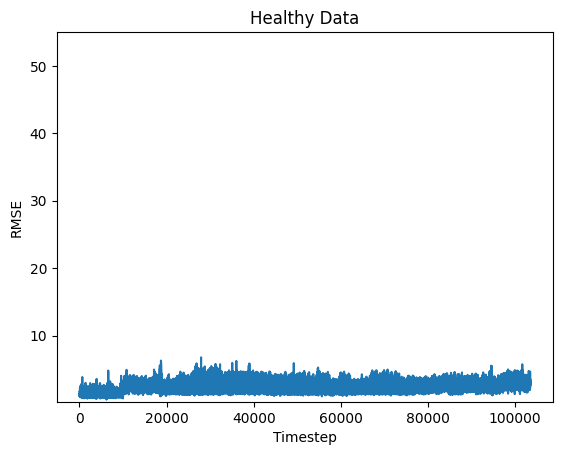

In [3]:
test_cells_healthy = [
    'data/preprocessed/UL-PUR_R15-EX4_18650_NCA_23C_2.5-96.5_0.5-0.5C_d_timeseries.pkl'
]
X_test, _, _ = get_windows(cells=test_cells_healthy, window_size=100)

healthy_predictions = autoencoder_model.predict(X_test)
print(healthy_predictions.shape, X_test.shape)
plot_results(X_test, healthy_predictions, 'Healthy Data')

65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step
(2062, 100, 1) (2062, 100, 1)


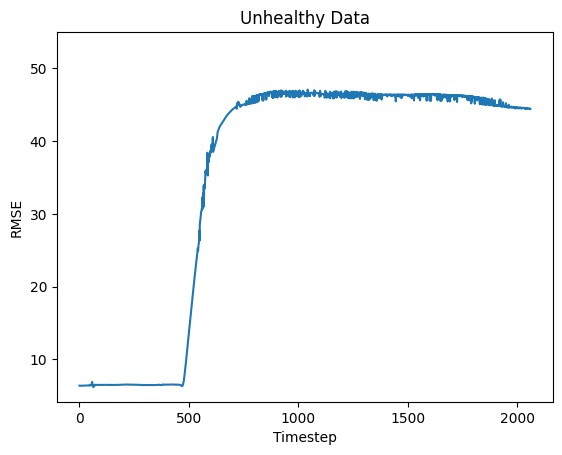

In [4]:
test_cells_unhealthy = [
    'data/preprocessed/LFP_15Ah_60SOC_cell1_MAX.pkl'
]
X_test_unhealthy, _, _ = get_windows(cells=test_cells_unhealthy, window_size=100)

unhealthy_predictions = autoencoder_model.predict(X_test_unhealthy)
print(unhealthy_predictions.shape, X_test_unhealthy.shape)
plot_results(X_test_unhealthy, unhealthy_predictions, 'Unhealthy Data')